# Breast Cancer Histopathology Classifier

This project uses histopathology data from the [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data) to predict whether breast cell samples are malignant or benign.

## About the Data

Each sample is a digitized image of a fine needle aspirate (FNA) of a breast mass. The cell nuclei of each sample are examined and the mean, standard error, and worst/largest (mean of the 3 largest values) of each characteristic is recorded, leading to 30 features for 10 characteristics:
- radius (mean of distances from center to points on the perimeter)
    - cannot be negative or 0
    - Malignant cells have larger radius than normal.
- texture (standard deviation of gray-scale values)
    - can be 0 but not negative
    - if SD of gray-scale values is low, the nucleus appears smooth b/c chromatin is evenly dispersed, which is typical of normal, healthy, benign cells.
    - if high, nucleus looks grainy or blotchy, indicating uneven clumping and structural irregularities, which may indicate malignancy.
- perimeter
    - cell nucleus with irregular, large perimeter indicates malignancy.
    - cannot be 0 or negative
- area
    - enlarged area indicates malignancy
    - cannot be 0 or negative
- smoothness (local variation in radius lengths)
    - 0 means totally smooth, negative values not possible
    - the less smooth it is, the more likely it's malignant
- compactness (perimeter^2 / area - 1.0)
    - higher compactness indicates malignancy
    - cannot be 0 or negative
- concavity (severity of concave portions of the contour)
    - high degree of concavity is typically associated with malignant cells
    - can be 0 but not negative
- concave points (number of concave portions of the contour)
    - higher number typically indicates malignancy
    - can be 0 but not negative
- symmetry (computed by measuring the major axis through the center and then measuring the length difference between lines perpendicular to the major axis to the cell boundary in both directions.)
    - asymmetry indicates malignancy
    - cannot be negative
- fractal dimension ("coastline approximation" - 1)
    - higher fractal dimension typically indicates  malignancy b/c it reflects highly chaotic, jagged boundaries and complex, uneven chromatin arrangements
    - cannot be 0 or negative 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.preprocessing import StandardScaler

## Prepping Data

### Load data

In [2]:
df = pd.read_csv('data.csv')
df = df.drop('Unnamed: 32', axis=1)  # there is an unnamed 32nd column with all NaN, so we remove that
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### Check for missing values, duplicates, if all IDs are unique

In [13]:
df.info()  # result: no missing values

print('\nDuplicates:', df.duplicated().sum())  # result: no duplicates

# check if all ids are unique
unique_id = df['id'].is_unique
print('\nUnique IDs:', unique_id)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### Check for garbage values

Features are not standardized or scaled, so garbage values (e.g. 0s or negatives that are not possible) may be present and must be removed.

In [ ]:
features = df.loc[:, 'radius_mean':'fractal_dimension_mean']
any_neg = features.columns[(features < 0).any()].tolist()
any_nil = features.columns[(features == 0).any()].tolist()
print(any_neg)  # result: no negative values
print(any_nil)  # only concavity_mean and concave points_mean columns have 0 as values, which are allowed

# so no garbage values

[]
['concavity_mean', 'concave points_mean']


In [3]:
# convert diagnosis to 0s and 1s (1 = malignant, 0 = benign)
df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


## Exploratory Data Analysis

Can this data actually be used to predict whether cells are malignant or benign? How do we use this data to predict that?

In [4]:
# create dataframe for plotting only
scaler_for_viz = StandardScaler()
characteristics_only = df.drop(columns=['diagnosis', 'id'])

df_viz_scaled = pd.DataFrame(scaler_for_viz.fit_transform(characteristics_only), columns=characteristics_only.columns)
df_viz_scaled['diagnosis'] = df['diagnosis'].values

df_viz_scaled

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,1
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,1
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,1
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,1
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091,1
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978,1
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409,1
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635,1


### Do the features (means and worsts) actually distinguish benign cells from malignant cells?

use split violin plots for each characteristic, 1 half for benign, other half for malignant. plot means and then worsts. if the means plot shows a massive difference between benign and malignant halves, that feature can distinguish benign vs malignancy in most cases. but if a massive difference between benign and malignant halves only appears in the worsts plot, that feature can distinguish benign vs malignancy in cases that might be false negatives.

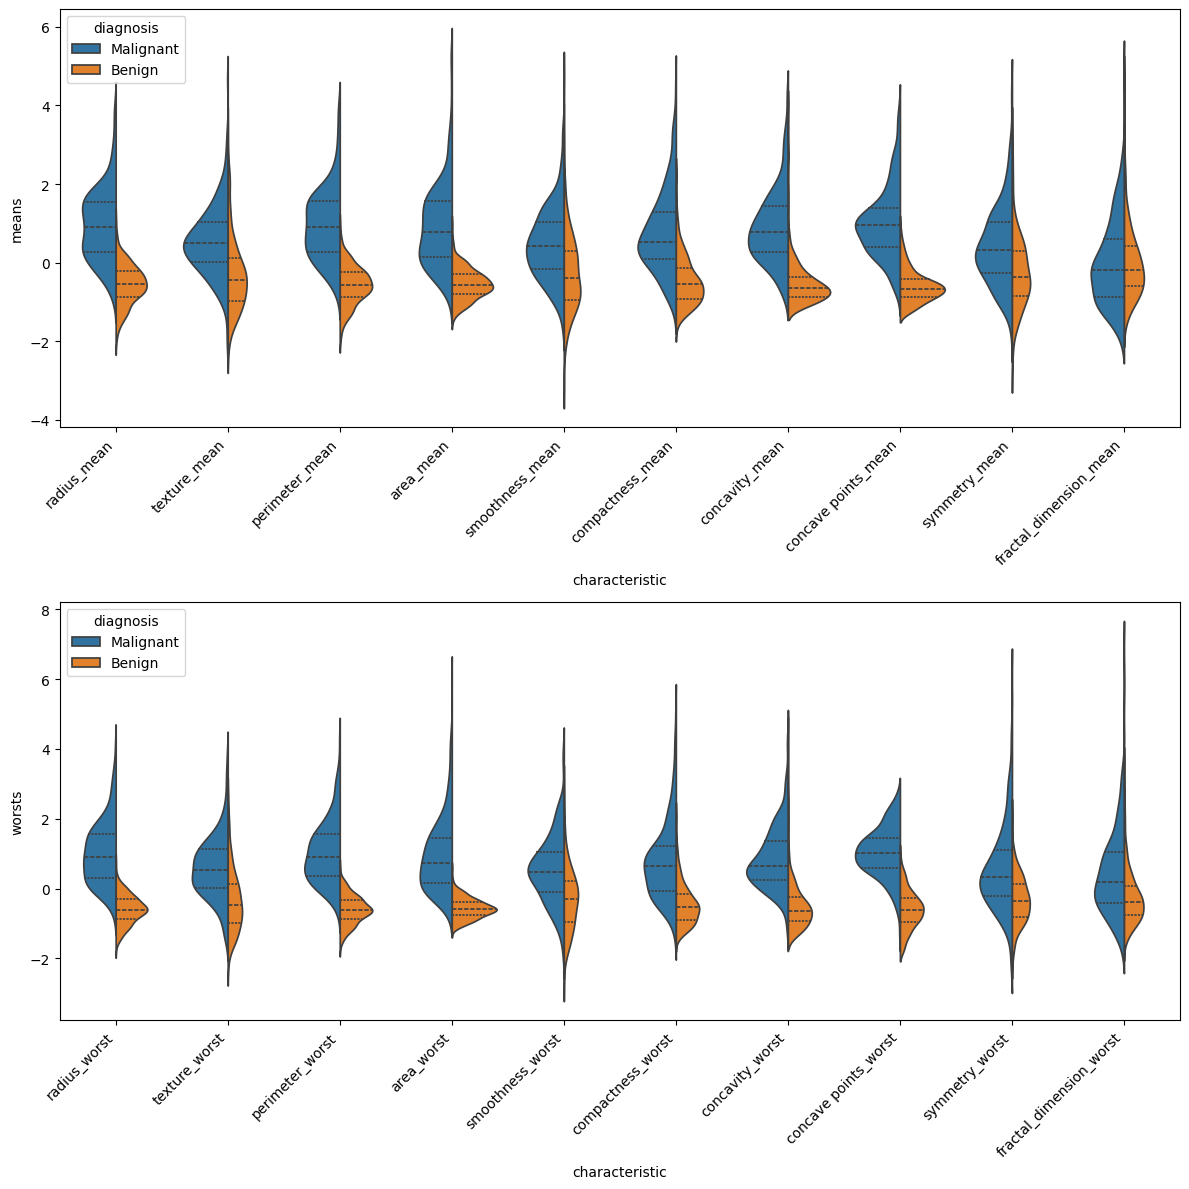

In [ ]:
figs, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12,12))
df_viz_scaled['diagnosis'] = df_viz_scaled['diagnosis'].map({1: 'malignant', 0: 'benign'})

# violin plot for means

means_col_names = df_viz_scaled.columns[df_viz_scaled.columns.get_loc('radius_mean') : df_viz_scaled.columns.get_loc('fractal_dimension_mean') + 1]  # +1 b/c dealing with list indices w/c don't include the item at the given end index
means = df_viz_scaled.loc[:,['diagnosis'] + list(means_col_names)]
long_means = means.melt(id_vars='diagnosis', var_name='characteristic', value_name='means')

v_means = sns.violinplot(data=long_means, x='characteristic', y='means', hue='diagnosis', split=True, ax=ax1, inner='quart')

# violin plot for worsts

worsts_col_names = df_viz_scaled.columns[df_viz_scaled.columns.get_loc('radius_worst') : df_viz_scaled.columns.get_loc('fractal_dimension_worst') + 1]  # +1 b/c dealing with list indices w/c don't include the item at the given end index
worsts = df_viz_scaled.loc[:,['diagnosis'] + list(worsts_col_names)]
long_worsts = worsts.melt(id_vars='diagnosis', var_name='characteristic', value_name='worsts')

v_worsts = sns.violinplot(data=long_worsts, x='characteristic', y='worsts', hue='diagnosis', split=True, ax=ax2, inner='quart')

# make x axis labels diagonal for both plots
plt.xticks(rotation=45, ha='right')

ticks_means = v_means.get_xticks()
v_means.set_xticks(ticks_means)
v_means.set_xticklabels(v_means.get_xticklabels(), rotation=45, ha='right')

ticks_worsts = v_worsts.get_xticks()
v_worsts.set_xticks(ticks_worsts)
v_worsts.set_xticklabels(v_worsts.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# test for statistically significant difference too. 
# unpaired student's t-test if data is normally distributed for both malignant and benign groups
# Mann-Whitney U test if data is skewed
# Mann-Whitney U test is a non-parametric statistical test used to determine if there are statistically significant differences between two independent groups. Often used as an alternative to the independent t-test, it does not require data to be normally distributed and is ideal for skewed data, small sample sizes, or ordinal variables

In [ ]:
# TODO are there any interactions between combos of features? create heatmap of features to check


# TODO confusion matrix